In [3]:
import ctypes
try:
    ctypes.CDLL('/usr/lib/aarch64-linux-gnu/libgomp.so.1', mode=ctypes.RTLD_GLOBAL)
except OSError:
    pass

import os
import sys
sys.path.append('/usr/local/lib')

import pyrealsense2 as rs
import numpy as np
import cv2
import math
import time

from IPython.display import display, clear_output, Image as IPythonImage

print("Wszystkie moduły załadowane pomyślnie!")

Wszystkie moduły załadowane pomyślnie!


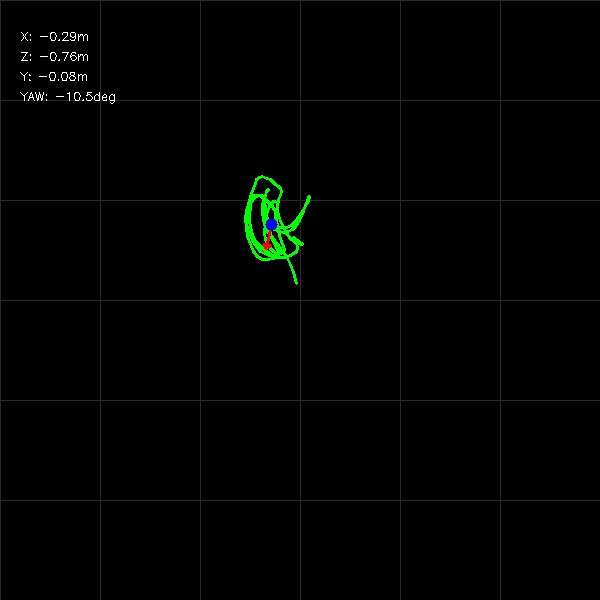


Pętla zatrzymana przez użytkownika.
Kamera T265 zatrzymana pomyślnie.


In [4]:
def quaternion_yaw(qx, qy, qz, qw):
    siny_cosp = 2 * (qw * qy + qz * qx)
    cosy_cosp = 1 - 2 * (qx * qx + qy * qy)
    return math.atan2(siny_cosp, cosy_cosp)

pipe = rs.pipeline()
config = rs.config()
config.enable_stream(rs.stream.pose)

print("Uruchamianie T265...")
pipe.start(config)

map_size = 600
trail_map = np.zeros((map_size, map_size, 3), dtype=np.uint8)
traj = []
scale = 100
cent_x, cent_y = map_size // 2, map_size // 2

print("Wizualizacja wystartowała. Aby zatrzymać, kliknij stop.")
is_running = True
time.sleep(1.0)
try:
    while True:
        frames = pipe.poll_for_frames()
        if not frames:
            time.sleep(0.03)
            continue
            
        pose_frame = frames.get_pose_frame()
        if not pose_frame:
            continue

        data = pose_frame.get_pose_data()
        x_m = data.translation.x
        z_m = -data.translation.z
        y_m = data.translation.y
        
        pixel_x = int(cent_x + (x_m * scale))
        pixel_y = int(cent_y + (z_m * scale))
        current_pos = (pixel_x, pixel_y)
        
        if not traj or traj[-1] != current_pos:
            traj.append(current_pos)

        display_map = trail_map.copy()
        
        for i in range(-5, 6):
            cv2.line(display_map, (cent_x + i * scale, 0), (cent_x + i * scale, map_size), (40, 40, 40), 1)
            cv2.line(display_map, (0, cent_y + i * scale), (map_size, cent_y + i * scale), (40, 40, 40), 1)

        if len(traj) > 1:
            for i in range(1, len(traj)):
                cv2.line(display_map, traj[i-1], traj[i], (0, 255, 0), 2)

        qx, qy, qz, qw = data.rotation.x, data.rotation.y, data.rotation.z, data.rotation.w
        yaw = quaternion_yaw(qx, qy, qz, qw)
        arrow_length = 25
        arrow_end_x = int(pixel_x + arrow_length * math.sin(yaw))
        arrow_end_y = int(pixel_y + arrow_length * math.cos(yaw))
        cv2.arrowedLine(display_map, (pixel_x, pixel_y), (arrow_end_x, arrow_end_y), (0, 0, 255), 2, tipLength=0.2)
        cv2.circle(display_map, (pixel_x, pixel_y), 6, (255, 0, 0), -1)
        
        cv2.putText(display_map, f"X: {x_m:+.2f}m", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)
        cv2.putText(display_map, f"Z: {z_m:+.2f}m", (20, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)
        cv2.putText(display_map, f"Y: {y_m:+.2f}m", (20, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)
        cv2.putText(display_map, f"YAW: {math.degrees(yaw):+.1f}deg", (20, 100), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)

        _, encoded_img = cv2.imencode('.jpg', display_map)
        clear_output(wait=True)
        display(IPythonImage(data=encoded_img.tobytes()))
        
        time.sleep(0.01)

except KeyboardInterrupt:
    print("\nPętla zatrzymana przez użytkownika.")
except Exception as e:
    print("Error:", e)
finally:
    if is_running:
        pipe.stop()
        print("Kamera T265 zatrzymana pomyślnie.")